In [7]:
import numpy as np
import matplotlib.pyplot as plt

True labels:      [0 0 1 1]
Predicted labels: [0 0 1 1]


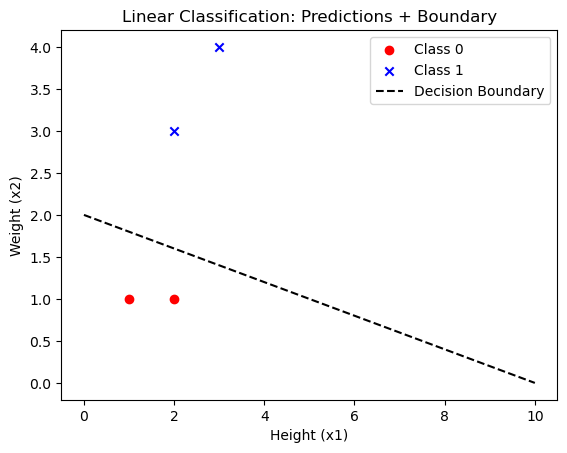

In [28]:
# Our small dataset (height = x1, weight = x2)
X = np.array([[1,1],[2,1],[2,3],[3,4]])
y_true = np.array([0,0,1,1])

# --- Prediction function ---
def predict(x):
    score = x[0] + 5*x[1] - 10   # decision rule
    return 1 if score >= 0 else 0

# Predict for all points
y_pred = np.array([predict(x) for x in X])

print("True labels:     ", y_true)
print("Predicted labels:", y_pred)

# --- Plot data points ---
for label, marker, color in [(0, "o", "red"), (1, "x", "blue")]:
    plt.scatter(X[y_true==label, 0], X[y_true==label, 1], 
                marker=marker, color=color, label=f"Class {label}")

# --- Plot decision boundary ---
# equation: x1 + 5x2 = 10  →  x2 = (-1/5)x1 + 2
x1_vals = np.linspace(0, 10, 100)
x2_vals = (-1/5) * x1_vals + 2
plt.plot(x1_vals, x2_vals, "k--", label="Decision Boundary")

plt.xlabel("Height (x1)")
plt.ylabel("Weight (x2)")
plt.legend()
plt.title("Linear Classification: Predictions + Boundary")
plt.show()

Epoch 1: 2 mistakes
Epoch 2: 3 mistakes
Epoch 3: 4 mistakes
Epoch 4: 3 mistakes
Epoch 5: 3 mistakes
Epoch 6: 3 mistakes
Epoch 7: 3 mistakes
Epoch 8: 4 mistakes
Epoch 9: 3 mistakes
Epoch 10: 3 mistakes
Epoch 11: 1 mistakes
Epoch 12: 0 mistakes
Epoch 13: 0 mistakes
Epoch 14: 0 mistakes
Epoch 15: 0 mistakes
Epoch 16: 0 mistakes
Epoch 17: 0 mistakes
Epoch 18: 0 mistakes
Epoch 19: 0 mistakes
Epoch 20: 0 mistakes
Final weights: [0.4 0.1]
Final bias: -2.3


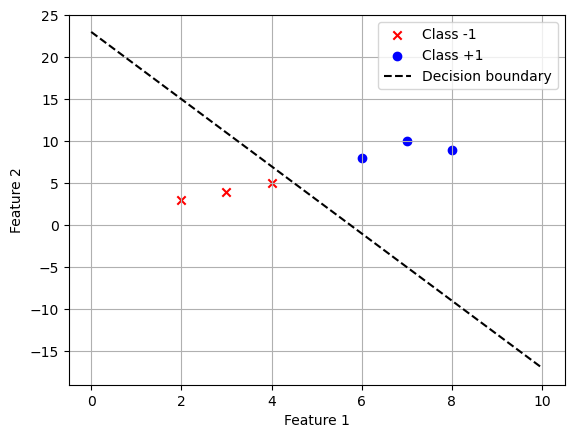

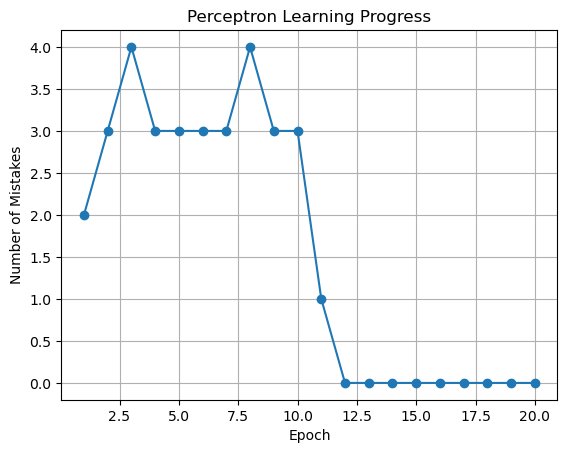

In [29]:
# 1. Create linearly separable data
X = np.array([[2, 3], [3, 4], [4, 5],   # class -1
              [6, 8], [7, 10], [8, 9]]) # class +1
y = np.array([-1, -1, -1, 1, 1, 1])     # labels

# 2. Initialize weights
w = np.zeros(2)  # [w1, w2]
b = 0            # bias
lr = 0.1         # learning rate

mistakes_per_epoch = []  # store number of mistakes in each epoch

# 3. Perceptron training
for epoch in range(20):  # train for 20 epochs
    mistakes = 0
    for xi, target in zip(X, y):
        prediction = np.sign(np.dot(w, xi) + b)
        if prediction != target:  # misclassified
            update = lr * (target - prediction)
            w += update * xi
            b += update
            mistakes += 1
    mistakes_per_epoch.append(mistakes)
    print(f"Epoch {epoch+1}: {mistakes} mistakes")

print("Final weights:", w)
print("Final bias:", b)

# 4. Plot data and decision boundary
for i, point in enumerate(X):
    if y[i] == 1:
        plt.scatter(point[0], point[1], color='blue', marker='o', label="Class +1" if i == 3 else "")
    else:
        plt.scatter(point[0], point[1], color='red', marker='x', label="Class -1" if i == 0 else "")

# Decision boundary: w1*x1 + w2*x2 + b = 0 → x2 = -(w1*x1 + b)/w2
x_vals = np.linspace(0, 10, 100)
y_vals = -(w[0] * x_vals + b) / w[1]
plt.plot(x_vals, y_vals, 'k--', label="Decision boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# 5. Plot mistakes per epoch
plt.plot(range(1, 21), mistakes_per_epoch, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Mistakes")
plt.title("Perceptron Learning Progress")
plt.grid(True)
plt.show()
